# Gradient Norm Monitoring (C4)

Track gradient magnitudes per layer to detect exploding gradients.

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from network import Network, NetworkConfig
from optimizer import Adam

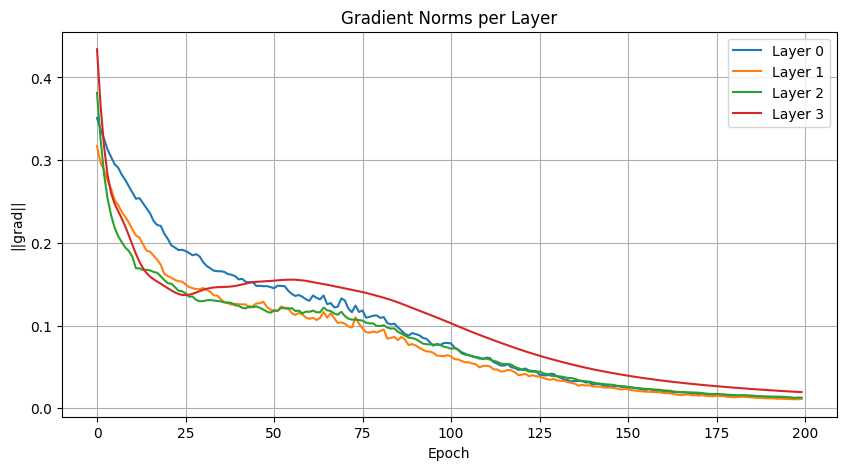

Layer 0: max norm = 0.3510  OK
Layer 1: max norm = 0.3172  OK
Layer 2: max norm = 0.3814  OK
Layer 3: max norm = 0.4342  OK

Clipping needed: NO


In [2]:
np.random.seed(42)
net = Network(NetworkConfig(layers=[30, 24, 24, 24, 2], activation='relu',
    loss='cross_entropy', output_activation='softmax', weights_initializer='heUniform'))
opt = Adam(learning_rate=0.001)

x = np.random.randn(100, 30)
y = np.zeros((100, 2))
y[np.arange(100), np.random.randint(0, 2, 100)] = 1

norms = {i: [] for i in range(len(net.weights))}

for _ in range(200):
    net.forward(x)
    nw, nb = net.backward(y)
    opt.update(net, nw, nb)
    for i, gw in enumerate(nw):
        norms[i].append(np.linalg.norm(gw))

plt.figure(figsize=(10, 5))
for i, n in norms.items():
    plt.plot(n, label=f'Layer {i}')
plt.title('Gradient Norms per Layer')
plt.xlabel('Epoch'); plt.ylabel('||grad||')
plt.legend(); plt.grid(True); plt.show()

threshold = 100.0
for i, n in norms.items():
    mx = max(n)
    print(f'Layer {i}: max norm = {mx:.4f}  {"EXPLODING" if mx > threshold else "OK"}')
print(f'\nClipping needed: {"YES" if any(max(n) > threshold for n in norms.values()) else "NO"}')